In [2]:
# Import thư viện
from google.cloud import bigquery
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
client = bigquery.Client(project="bi-recruitment-452004")

Các thay đổi được ghi nhận trong tuần Retention Rate D3 giảm:
- Game update version mới
- A/B Test
- UA mở rộng country sang Tier 2/3 kèm tăng spend

In [ ]:
# Tính RR chung
rr_query = """SELECT
    install_date,
    UPPER(operating_system) AS os,
    COUNT(user_pseudo_id) AS total_installs,
    SUM(_1) AS retained_d1,
    SUM(_3) AS retained_d3,
    SUM(_7) AS retained_d7,
    ROUND(SAFE_DIVIDE(SUM(_1), COUNT(user_pseudo_id)) * 100, 2) AS rr_d1_pct,
    ROUND(SAFE_DIVIDE(SUM(_3), COUNT(user_pseudo_id)) * 100, 2) AS rr_d3_pct,
    ROUND(SAFE_DIVIDE(SUM(_7), COUNT(user_pseudo_id)) * 100, 2) AS rr_d7_pct
FROM `bi-recruitment-452004.ef_capstone.retention_cohort`
WHERE install_date BETWEEN '2026-03-10' AND '2026-04-05'
GROUP BY install_date, os
ORDER BY install_date ASC, os ASC;
"""
df_rr = client.query(rr_query).to_dataframe()
display(df_rr)

,install_date,os,total_installs,retained_d1,retained_d3,retained_d7,rr_d1_pct,rr_d3_pct,rr_d7_pct
0,2026-03-10,ANDROID,8268,4004,2897,2241,48.43,35.04,27.10
1,2026-03-10,IOS,4445,2349,1724,1365,52.85,38.79,30.71
2,2026-03-11,ANDROID,6756,3249,2303,1821,48.09,34.09,26.95
3,2026-03-11,IOS,4160,2202,1620,1270,52.93,38.94,30.53
4,2026-03-12,ANDROID,6691,3280,2274,1807,49.02,33.99,27.01
5,2026-03-12,IOS,4077,2163,1540,1206,53.05,37.77,29.58
6,2026-03-13,ANDROID,6094,2890,2067,1567,47.42,33.92,25.71
7,2026-03-13,IOS,4112,2117,1620,1210,51.48,39.40,29.43
8,2026-03-14,ANDROID,6768,3233,2259,1813,47.77,33.38,26.79
9,2026-03-14,IOS,4842,2645,1923,1504,54.63,39.71,31.06


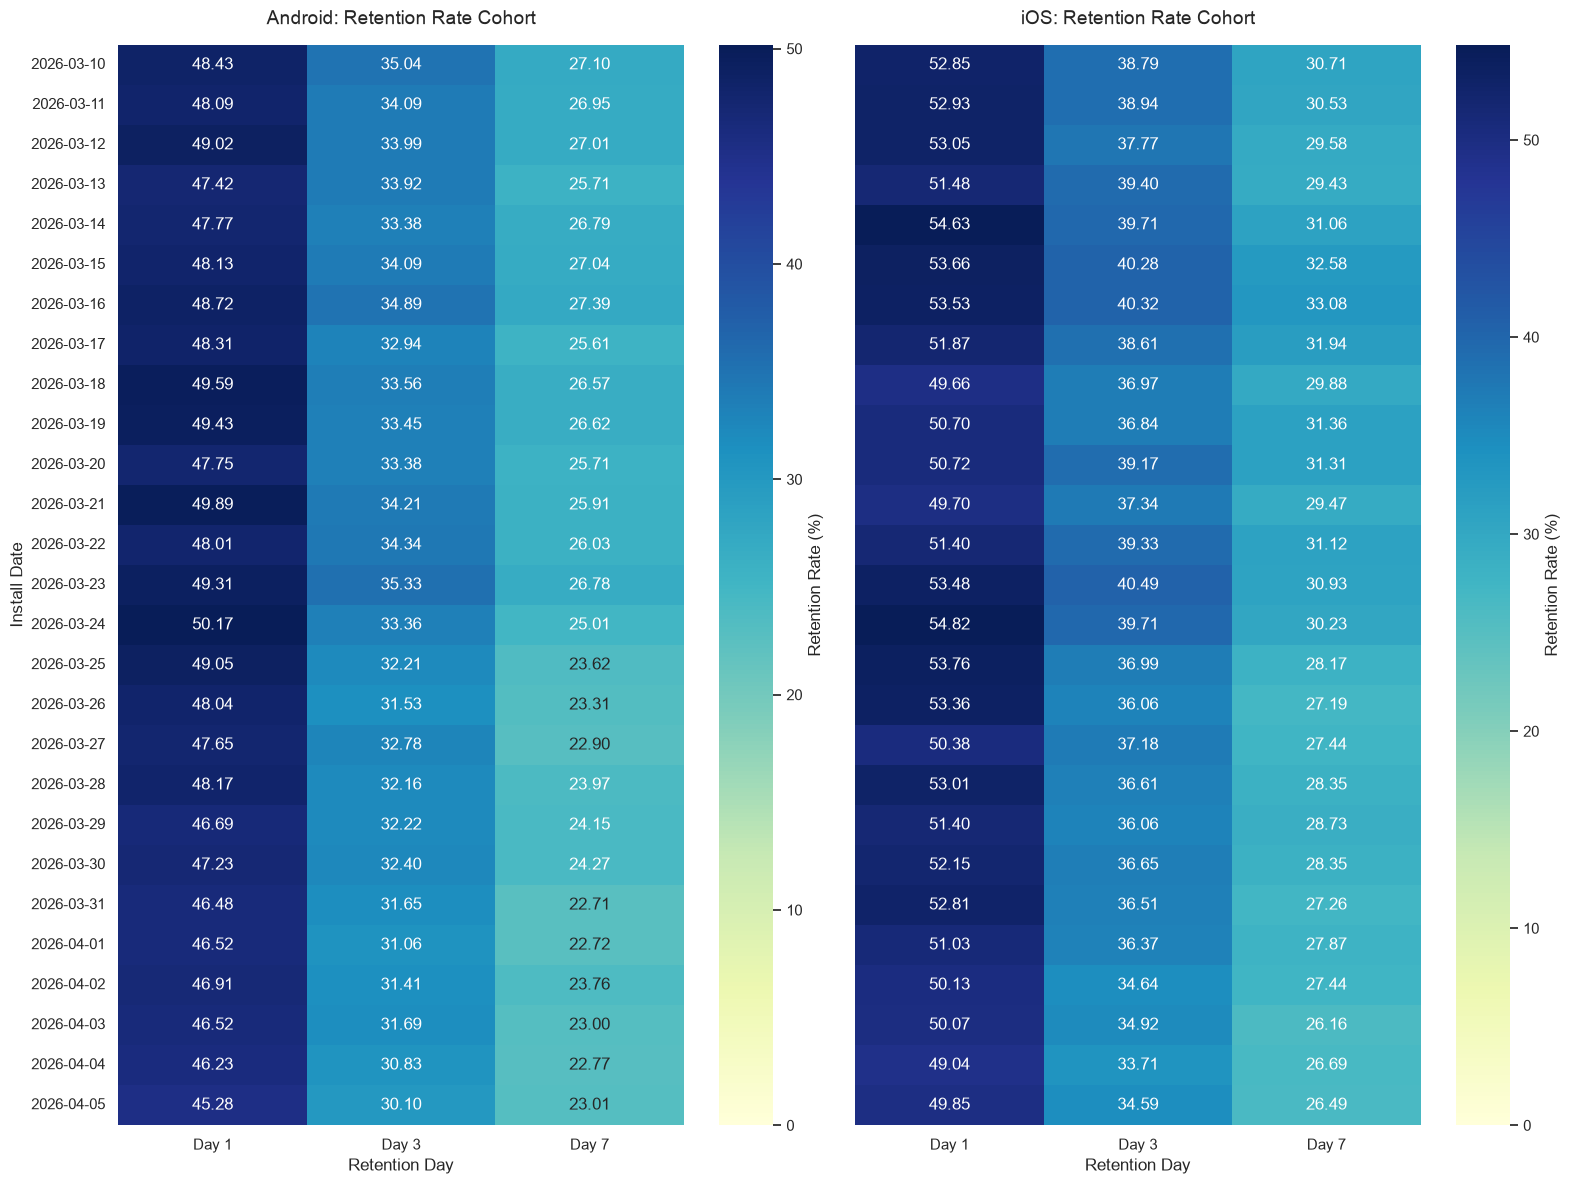

In [17]:
df_os = df_rr[['install_date', 'os', 'rr_d1_pct', 'rr_d3_pct', 'rr_d7_pct']].copy()

df_android = df_os[df_os['os'] == 'ANDROID'][['install_date', 'rr_d1_pct', 'rr_d3_pct', 'rr_d7_pct']].copy()
df_ios = df_os[df_os['os'] == 'IOS'][['install_date', 'rr_d1_pct', 'rr_d3_pct', 'rr_d7_pct']].copy()

df_android['install_date'] = df_android['install_date'].astype(str)
df_android.set_index('install_date', inplace=True)
df_android.columns = ['Day 1', 'Day 3', 'Day 7']

df_ios['install_date'] = df_ios['install_date'].astype(str)
df_ios.set_index('install_date', inplace=True)
df_ios.columns = ['Day 1', 'Day 3', 'Day 7']

fig, axes = plt.subplots(1, 2, figsize=(16, 12), sharey=True)

sns.heatmap(df_android, 
            annot=True, 
            fmt=".2f", 
            cmap="YlGnBu", 
            vmin=0, 
            ax=axes[0],
            cbar_kws={'label': 'Retention Rate (%)'})
axes[0].set_title('Android: Retention Rate Cohort', fontsize=14, pad=15)
axes[0].set_ylabel('Install Date', fontsize=12)
axes[0].set_xlabel('Retention Day', fontsize=12)

sns.heatmap(df_ios, 
            annot=True, 
            fmt=".2f", 
            cmap="YlGnBu", 
            vmin=0, 
            ax=axes[1],
            cbar_kws={'label': 'Retention Rate (%)'})
axes[1].set_title('iOS: Retention Rate Cohort', fontsize=14, pad=15)
axes[1].set_ylabel('') # Ẩn nhãn trục Y bên iOS vì đã dùng chung với Android bên trái
axes[1].set_xlabel('Retention Day', fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
# Tính RR riêng cho từng Tier
rr_tier_query = """SELECT
    install_date,
    UPPER(operating_system) AS os,
    CASE 
        WHEN tier = 'Tier01' THEN 'Tier 1'
        WHEN tier = 'Tier02' THEN 'Tier 2'
        WHEN tier = 'Tier03' THEN 'Tier 3'
        ELSE 'Tier 4'
    END AS tier_group,
    COUNT(user_pseudo_id) AS total_installs,
    SUM(_3) AS retained_d3,
    ROUND(SAFE_DIVIDE(SUM(_3), COUNT(user_pseudo_id)) * 100, 2) AS rr_d3_pct
FROM `bi-recruitment-452004.ef_capstone.retention_cohort`
WHERE install_date BETWEEN '2026-03-10' AND '2026-04-05'
GROUP BY install_date, os, tier_group
ORDER BY install_date ASC, os ASC, tier_group ASC;
""" 
df_rr_tier = client.query(rr_tier_query).to_dataframe()
display(df_rr_tier)

,install_date,os,tier_group,total_installs,retained_d3,rr_d3_pct
0,2026-03-10,ANDROID,Tier 1,1675,557,33.25
1,2026-03-10,ANDROID,Tier 2,1378,515,37.37
2,2026-03-10,ANDROID,Tier 3,3171,1072,33.81
3,2026-03-10,ANDROID,Tier 4,2044,753,36.84
4,2026-03-10,IOS,Tier 1,2132,794,37.24
5,2026-03-10,IOS,Tier 2,729,282,38.68
6,2026-03-10,IOS,Tier 3,1246,504,40.45
7,2026-03-10,IOS,Tier 4,338,144,42.60
8,2026-03-11,ANDROID,Tier 1,1416,465,32.84
9,2026-03-11,ANDROID,Tier 2,1215,460,37.86


- Tier 1: Australia, Canada, Japan, United Kingdom, United States
- Tier 2: Austria, Belgium, Denmark, France, Germany, Hong Kong, Ireland, Netherlands, New Zealand, Norway, Singapore, South Korea, Sweden, Switzerlan, Taiwan, U.S. Virgin Islands
- Tier 3: Bahamas, Botswana, Brazil, Bulgaria, Chad, Chile, Costa Rica, Croatia, Cuba, Cyprus, Czechia, Estonia, Finland, Greece, Guadeloupe, Guyana, Hungary, Iceland, Indonesia, Israel, Italy, Kazakhstan, Kuwait, Latvia, Lithuania, Luxembourg, Macao, Malaysia, Malta, Mexico, Myanmar (Burma), Oman, Panama, Papua New Guinea, Peru, Philippines, Poland, Portugal, Puerto Rico, Qatar, Romania, Russia, Réunion, Saudi Arabia, Slovakia, Slovenia, South Africa, Spain, Thailand, United Arab Emirates
- Tier 4: Afghanistan, Albania, Algeria, American Samoa, Andorra, Angola, Antigua & Barbuda, Argentina, Armenia, Aruba, Azerbaijan, Bahrain, Bangladesh, Belarus, Belize, Benin, Bermuda, Bolivia, Bosnia & Herzegovina, British Virgin Islands, Brunei, Burkina Faso, Burundi, Cambodia, Cameroon, Cape Verde, Central African Republic, China, Colombia, Congo - Brazzaville, Congo - Kinshasa, Cook Islands, Curaçao, Côte d’Ivoire, Djibouti, Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Eswatini, Ethiopia, French Guiana, French Polynesia, Gabon, Gambia, Georgia, Ghana, Guam, Guatemala
- NULL: NULL, Isle of Man, South Sudan, Türkiye

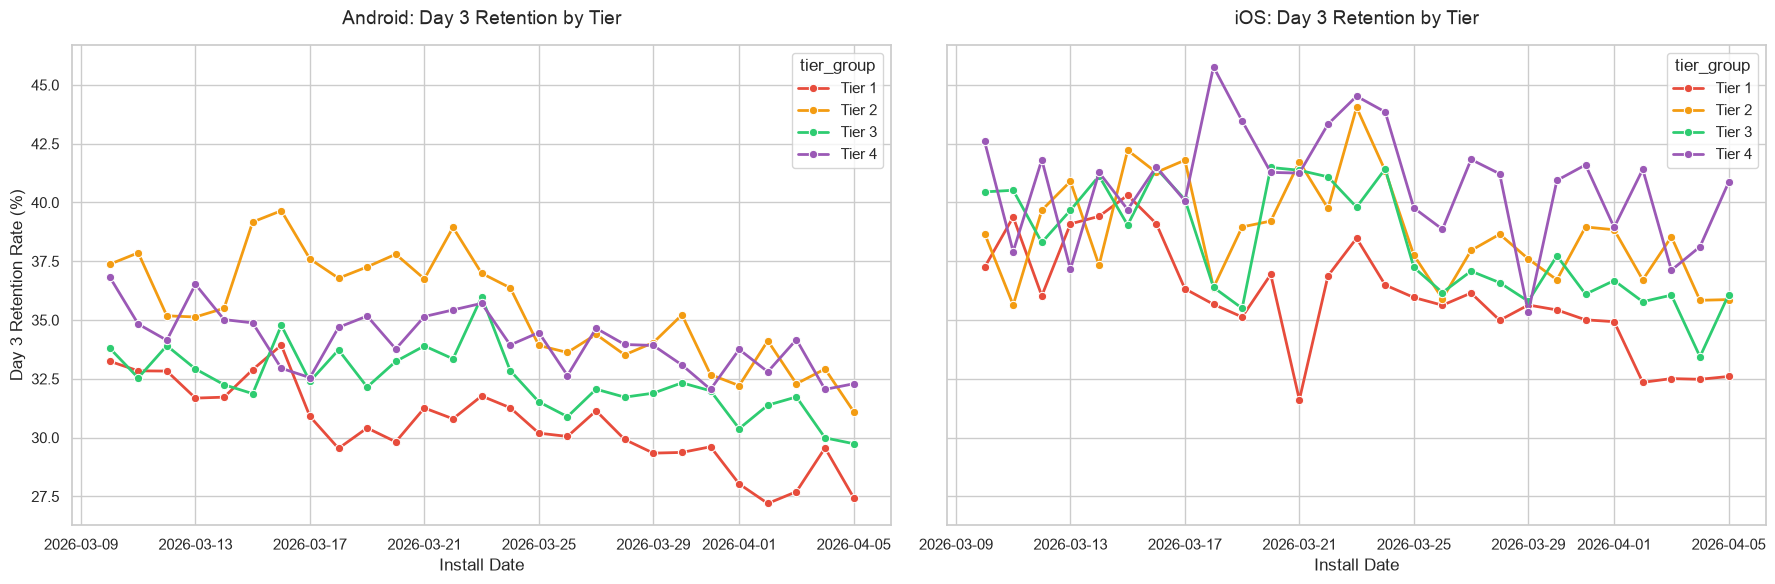

In [25]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

df_android = df_rr_tier[df_rr_tier['os'] == 'ANDROID']
df_ios = df_rr_tier[df_rr_tier['os'] == 'IOS']

sns.lineplot(data=df_android, x='install_date', y='rr_d3_pct', hue='tier_group', 
             marker='o', linewidth=2, ax=axes[0], 
             palette=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6']) 
axes[0].set_title('Android: Day 3 Retention by Tier', fontsize=14, pad=15)
axes[0].set_xlabel('Install Date', fontsize=12)
axes[0].set_ylabel('Day 3 Retention Rate (%)', fontsize=12)

sns.lineplot(data=df_ios, x='install_date', y='rr_d3_pct', hue='tier_group', 
             marker='o', linewidth=2, ax=axes[1], 
             palette=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6'])
axes[1].set_title('iOS: Day 3 Retention by Tier', fontsize=14, pad=15)
axes[1].set_xlabel('Install Date', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()